# 01 · Beijing PM2.5 — Advanced EDA I (quality · distributions · missingness)

## Part 1 — Advanced EDA I: Data Quality, Distributions & Missingness

This is a *thorough* exploratory pass — the kind you do before trusting any model. Three jobs:

1. **Audit the data quality** — types, ranges, impossible values, zero-inflation, duplicates.
2. **Characterise every variable** — distributions, the four moments, normality, and which need
   transforming.
3. **Dissect the missingness** — not just *how much*, but its *shape* and *mechanism*, because how
   you later impute depends entirely on this.

(Temporal, meteorological, extreme-event and multivariate structure are explored in **Part 2**.)

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

df = data.clean()
NUM = df.select_dtypes('number').columns.tolist()
print('rows:', len(df), '| numeric cols:', NUM)

setup ok | numpy 2.1.3 | pandas 2.3.3
rows: 43824 | numeric cols: ['pm25', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']


### 1. Data-quality audit

Before any analysis, profile every column: type, missingness, cardinality, range, and how often it
is exactly zero. This one table catches most data problems at a glance.

In [2]:
prof = pd.DataFrame({"dtype": df.dtypes.astype(str),
                     "missing": df.isna().sum(),
                     "miss%": (100*df.isna().mean()).round(2),
                     "unique": df.nunique()})
num = df[NUM]
prof.loc[NUM, "min"] = num.min(); prof.loc[NUM, "max"] = num.max()
prof.loc[NUM, "mean"] = num.mean().round(1); prof.loc[NUM, "zeros%"] = (100*(num == 0).mean()).round(1)
print(prof.to_string())

             dtype  missing  miss%  unique     min     max    mean  zeros%
pm25       float64     2067   4.72     581    0.00   994.0    98.6     0.0
DEWP         int64        0   0.00      69  -40.00    28.0     1.8     1.9
TEMP       float64        0   0.00      64  -19.00    42.0    12.4     2.6
PRES       float64        0   0.00      60  991.00  1046.0  1016.4     0.0
wind_dir  category        0   0.00       4     NaN     NaN     NaN     NaN
Iws        float64        0   0.00    2788    0.45   585.6    23.9     0.0
Is           int64        0   0.00      28    0.00    27.0     0.1    99.2
Ir           int64        0   0.00      37    0.00    36.0     0.2    95.9


In [3]:
# Sanity / impossible-value checks
print("duplicated timestamps:", int(df.index.duplicated().sum()))
print("negative pm25:", int((df.pm25 < 0).sum()), "| pm25 == 0 (valid 'very clean' hours):", int((df.pm25 == 0).sum()))
print("pressure range %.0f-%.0f hPa, temp %.0f-%.0f°C, dew point %.0f-%.0f°C  (all physically plausible)"
      % (df.PRES.min(), df.PRES.max(), df.TEMP.min(), df.TEMP.max(), df.DEWP.min(), df.DEWP.max()))
print("Is (snow hrs) zeros %.0f%% | Ir (rain hrs) zeros %.0f%%  -> ZERO-INFLATED (it rarely snows/rains)"
      % (100*(df.Is == 0).mean(), 100*(df.Ir == 0).mean()))

duplicated timestamps: 0
negative pm25: 0 | pm25 == 0 (valid 'very clean' hours): 2
pressure range 991-1046 hPa, temp -19-42°C, dew point -40-28°C  (all physically plausible)
Is (snow hrs) zeros 99% | Ir (rain hrs) zeros 96%  -> ZERO-INFLATED (it rarely snows/rains)


### 2. The target `pm25` — full univariate analysis

The four-view battery (shape / spread / percentiles / normality), the four moments, formal normality
tests, and the health-band (AQI) breakdown.

n                  41757.00
mean                  98.61
std                   92.05
skew                   1.80
excess_kurtosis        4.77
min                    0.00
median                72.00
max                  994.00

normality battery:
                        test  statistic  p_value  normal_at_5pct
                 Jarque-Bera 62162.7431      0.0           False
              D'Agostino K^2 15315.4724      0.0           False
Shapiro-Wilk (n=5000 sample)     0.8372      0.0           False


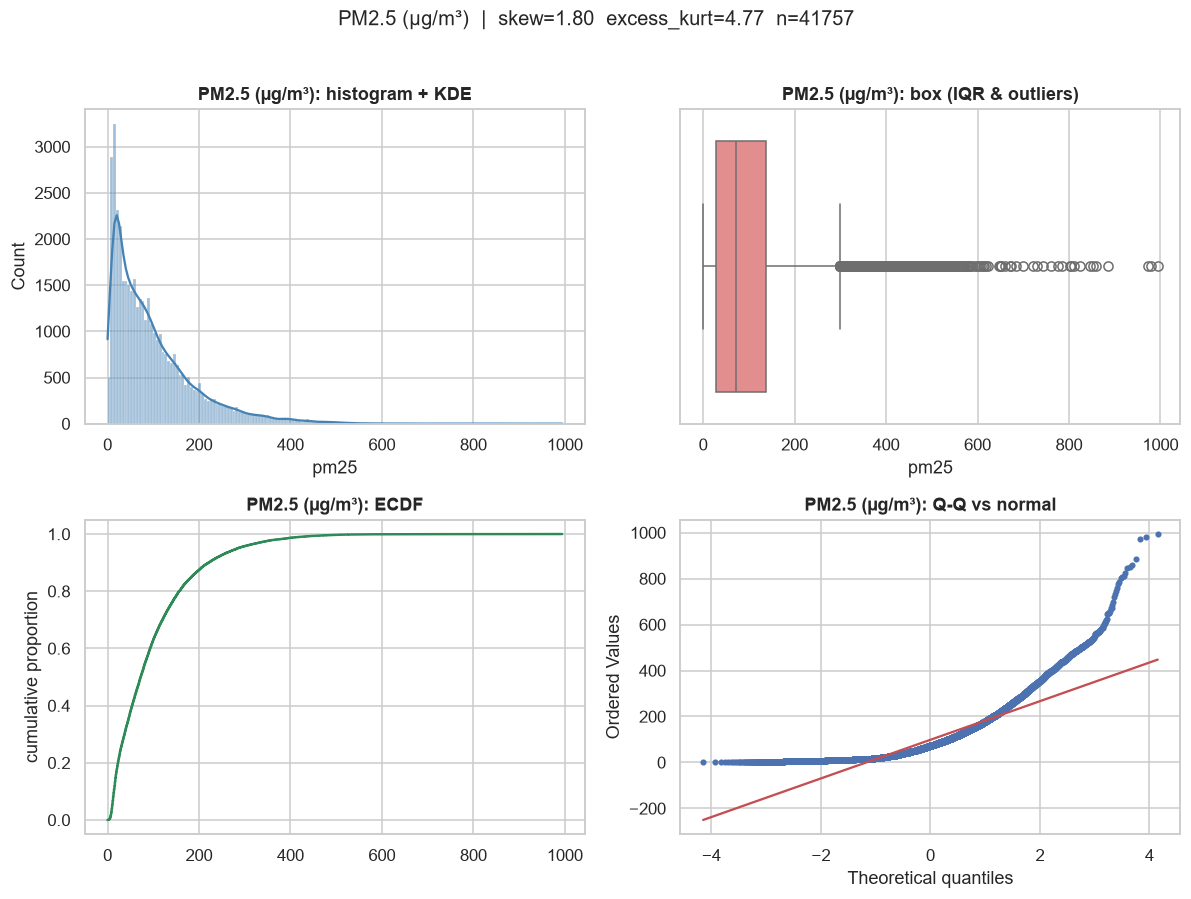

In [4]:
print(eda.moments(df["pm25"]).round(2).to_string())
print("\nnormality battery:"); print(eda.normality_battery(df["pm25"].dropna()).round(4).to_string(index=False))
fig = eda.four_view(df["pm25"].dropna(), "PM2.5 (µg/m³)", "p1_fourview.png"); plt.show()

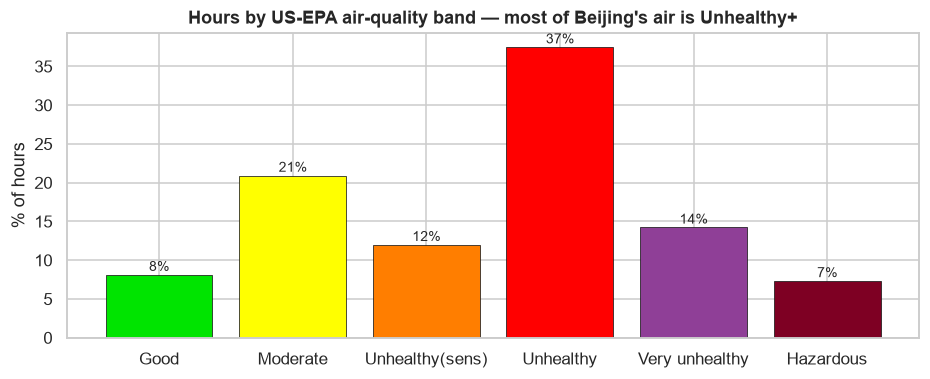

hours that are 'Unhealthy' or worse: 59%


In [5]:
aqi = data.aqi_category(df["pm25"]).value_counts(normalize=True).reindex(
      ["Good","Moderate","Unhealthy(sens)","Unhealthy","Very unhealthy","Hazardous"]) * 100
fig, ax = plt.subplots(figsize=(10, 3.6))
colors = ["#00e400","#ffff00","#ff7e00","#ff0000","#8f3f97","#7e0023"]
ax.bar(aqi.index, aqi.values, color=colors, edgecolor="k", lw=.5)
for i, v in enumerate(aqi.values): ax.text(i, v+0.5, f"{v:.0f}%", ha="center", fontsize=9)
ax.set_title("Hours by US-EPA air-quality band — most of Beijing's air is Unhealthy+"); ax.set_ylabel("% of hours")
eda.savefig(fig, "p1_aqi.png"); plt.show()
print("hours that are 'Unhealthy' or worse: %.0f%%" % aqi[["Unhealthy","Very unhealthy","Hazardous"]].sum())

### 3. Univariate sweep — every variable at once

A quick distribution of *each* column reveals shapes a summary table hides: PM2.5 and wind speed are
right-skewed; temperature/dew point are broad; snow and rain are spikes at zero (zero-inflated).

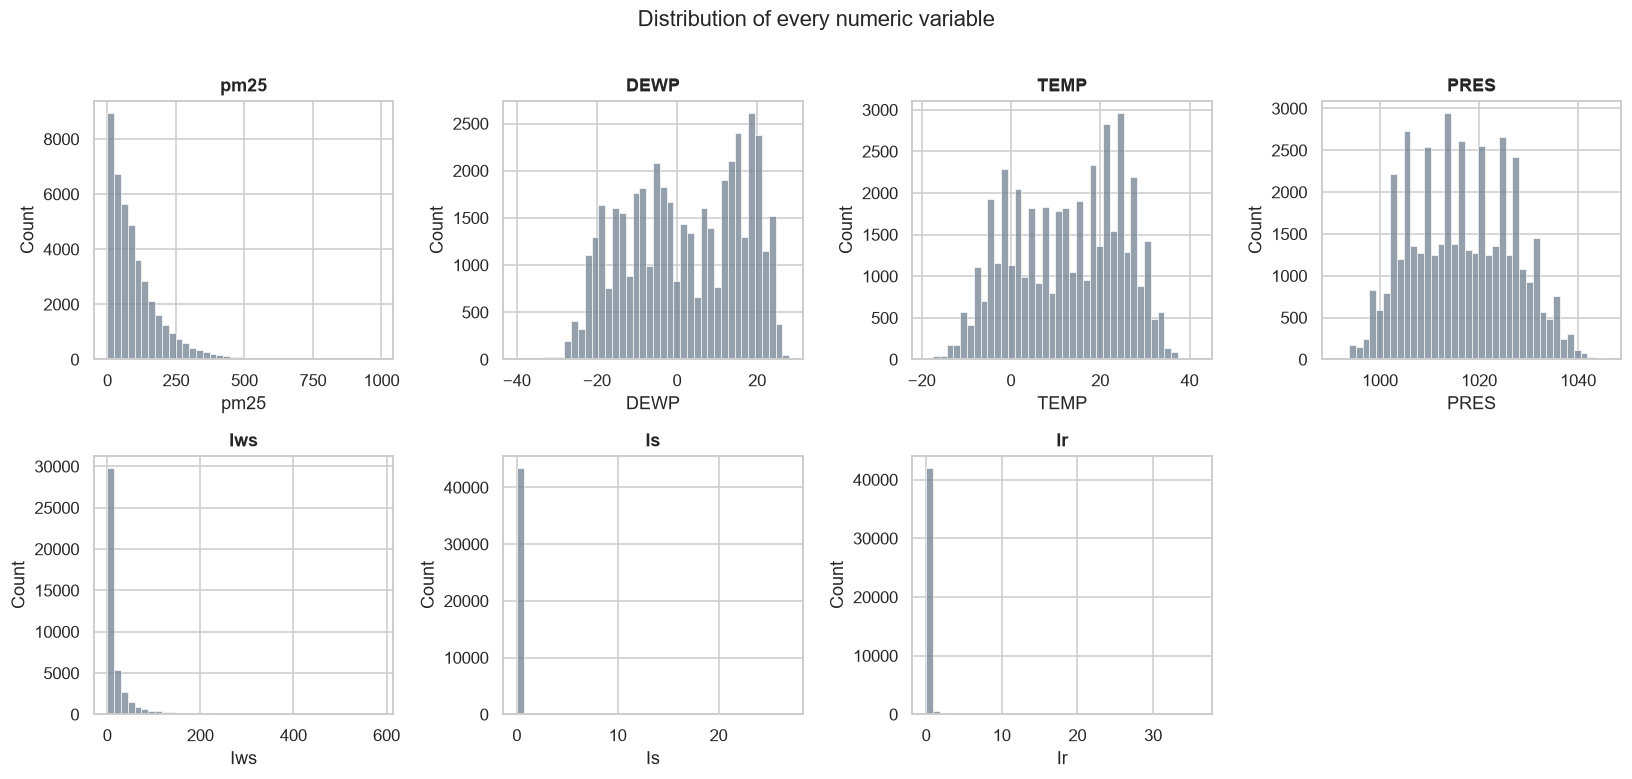

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, c in zip(axes.ravel(), NUM):
    sns.histplot(df[c].dropna(), bins=40, ax=ax, color="slategray"); ax.set_title(c)
axes.ravel()[-1].axis("off") if len(NUM) < 8 else None
fig.suptitle("Distribution of every numeric variable", y=1.01); fig.tight_layout()
eda.savefig(fig, "p1_univariate_grid.png"); plt.show()

In [7]:
shape = pd.DataFrame({"skew": num.skew().round(2), "excess_kurt": num.kurt().round(2),
                      "zeros%": (100*(num == 0).mean()).round(0)}).sort_values("skew", ascending=False)
print("shape of each variable (most skewed first):"); print(shape.to_string())

shape of each variable (most skewed first):
       skew  excess_kurt  zeros%
Is    19.48       449.08    99.0
Ir    11.66       174.42    96.0
Iws    4.30        23.42     0.0
pm25   1.80         4.77     0.0
PRES   0.10        -0.85     0.0
DEWP  -0.15        -1.20     2.0
TEMP  -0.16        -1.11     3.0


### 4. Transformations — taming the skew

Right-skewed, non-negative quantities (PM2.5, wind speed) become far more symmetric under a **log
(log1p) transform** — important later because many models and error metrics behave best on
roughly-symmetric targets.

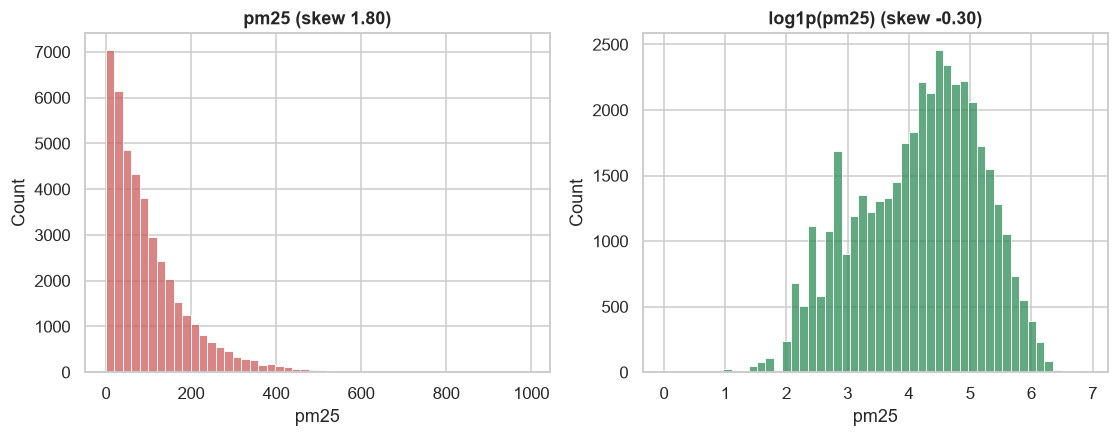

skew  pm25 1.80 -> log1p -0.30 | Iws 4.30 -> log1p 0.70


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["pm25"].dropna(), bins=50, ax=ax[0], color="indianred"); ax[0].set_title(f"pm25 (skew {df.pm25.skew():.2f})")
sns.histplot(np.log1p(df["pm25"].dropna()), bins=50, ax=ax[1], color="seagreen"); ax[1].set_title(f"log1p(pm25) (skew {np.log1p(df.pm25).skew():.2f})")
eda.savefig(fig, "p1_transform.png"); plt.show()
print("skew  pm25 %.2f -> log1p %.2f | Iws %.2f -> log1p %.2f" %
      (df.pm25.skew(), np.log1p(df.pm25).skew(), df.Iws.skew(), np.log1p(df.Iws).skew()))

### 5. The anatomy of the missingness

We already know 4.7% of `pm25` is missing. Now the *details* that decide how to handle it:

- **Where** in time the gaps fall (do outages cluster?),
- the **gap-length distribution** (many short vs few long),
- whether missingness is **seasonal** or tied to conditions,
- and a formal **MCAR** check.

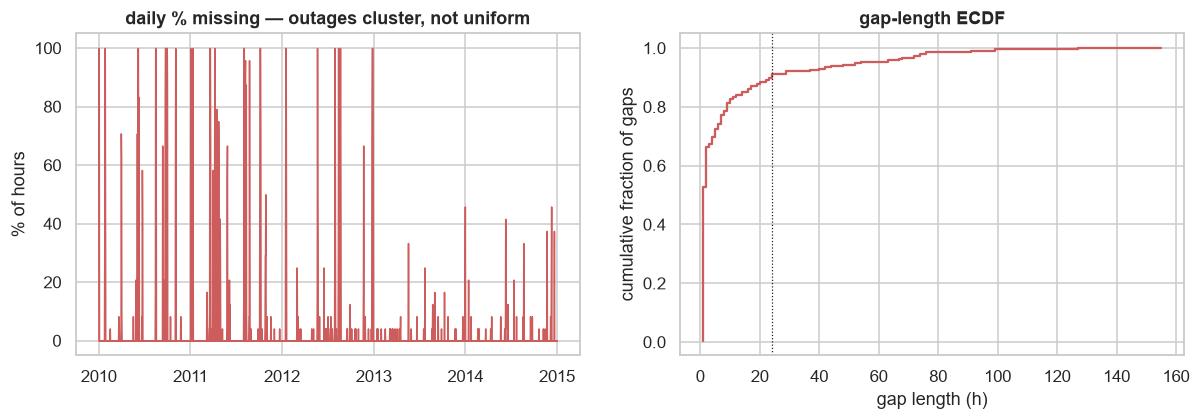

91% of gaps are <=24h (interpolatable); but 20 gaps exceed 24h, up to 155h.


In [9]:
runs = data.gap_runs(df["pm25"])
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
daily_miss = df.pm25.isna().resample("D").mean() * 100
ax[0].fill_between(daily_miss.index, daily_miss.values, color="indianred"); ax[0].set_title("daily % missing — outages cluster, not uniform"); ax[0].set_ylabel("% of hours")
x = np.sort(runs.values); ax[1].step(x, np.arange(1, len(x)+1)/len(x), color="indianred")
ax[1].set_title("gap-length ECDF"); ax[1].set_xlabel("gap length (h)"); ax[1].set_ylabel("cumulative fraction of gaps"); ax[1].axvline(24, color="k", ls=":", lw=.8)
eda.savefig(fig, "p1_missing_anatomy.png"); plt.show()
print("%.0f%% of gaps are <=24h (interpolatable); but %d gaps exceed 24h, up to %dh." %
      (100*(runs <= 24).mean(), int((runs > 24).sum()), int(runs.max())))

In [10]:
# Is missingness seasonal, and is it MCAR? Compare conditions on missing vs present hours.
from scipy.stats import ks_2samp
miss = df.pm25.isna()
print("missing rate by season-month (is it seasonal?):")
print((df.pm25.isna().groupby(df.index.month).mean()*100).round(1).to_string())
print("\nMCAR check — do weather distributions differ on missing vs present hours? (KS p-value)")
for c in data.WEATHER:
    p = ks_2samp(df.loc[miss, c], df.loc[~miss, c]).pvalue
    print("  %-5s KS p = %.3f %s" % (c, p, "(differs!)" if p < 0.01 else "(~same)"))
print("\n-> TEMP/DEWP/PRES differ significantly (with n=43k even tiny gaps register) => missingness leans MAR:")
print("   outages cluster in certain seasons/conditions. Magnitude is small, but impute USING the weather, not blindly.")

missing rate by season-month (is it seasonal?):
datetime
1      6.7
2      0.3
3      4.4
4      5.4
5      3.0
6      5.4
7      2.0
8     10.3
9      7.4
10     3.8
11     2.8
12     4.8

MCAR check — do weather distributions differ on missing vs present hours? (KS p-value)
  DEWP  KS p = 0.000 (differs!)
  TEMP  KS p = 0.000 (differs!)
  PRES  KS p = 0.000 (differs!)
  Iws   KS p = 0.379 (~same)
  Is    KS p = 0.998 (~same)
  Ir    KS p = 0.999 (~same)

-> TEMP/DEWP/PRES differ significantly (with n=43k even tiny gaps register) => missingness leans MAR:
   outages cluster in certain seasons/conditions. Magnitude is small, but impute USING the weather, not blindly.


### Takeaways (Part 1)

- **Quality is good** but for the target gaps: no duplicates, no impossible values, physically sane
  ranges; `Is`/`Ir` are **zero-inflated** (rarely snows/rains) — treat them carefully.
- **PM2.5 is severe and heavy-tailed** (skew 1.8): the majority of hours are **"Unhealthy" or worse**;
  a **log1p** transform makes it usable for modelling.
- **Missingness is structured**: clustered outages, mostly short gaps but a long tail up to 155h.
  A KS test finds a small-but-significant difference in temperature/pressure on missing vs present
  hours → the gaps lean **MAR** (outages cluster seasonally), not MCAR — so impute *using* the weather,
  and the long runs mean naive interpolation will distort. The motivation for Part 3's evaluated imputation.

**Next — Part 2 (Advanced EDA II):** temporal rhythms (diurnal × seasonal), the meteorology of
pollution (wind rose, dispersion), extreme episodes, and the multivariate structure (PCA & regimes).